Pareto chart - the Right way

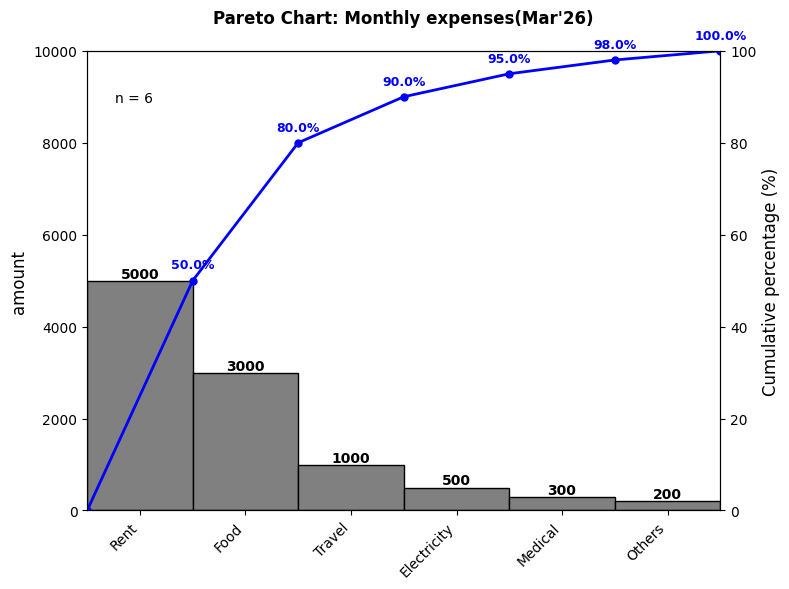

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Data Preparation
data = {
    'categories': [
        'Rent',
        'Food',
        'Travel',
        'Electricity',
        'Medical',
        'Others'
    ],
    'amount': [5000, 3000, 1000, 500, 300, 200]
}

df = pd.DataFrame(data)
df = df.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 2. Calculations
total_exp = df['amount'].sum()
cum_percentages = np.insert(np.cumsum(df['amount'].values) / total_exp * 100, 0, 0)

# 3. Plotting
fig, ax1 = plt.subplots(figsize=(8, 6))

bar_width = 1.0
x_indices = np.arange(len(df))

# Bar chart (Left Axis)
ax1.bar(x_indices, df['amount'], color='grey', edgecolor='black', width=bar_width, align='center')

# Remove the x-axis gap by setting limits from the far left of bar 0 to far right of last bar
ax1.set_xlim(-0.5, len(df) - 0.5)
ax1.set_ylim(0, 10000)
ax1.set_ylabel('amount', fontsize=12)

# 4. Secondary Axis for Cumulative Curve
ax2 = ax1.twinx()

# Line starts at -0.5 (Origin 0,0) and moves to the right edge of each bar
line_x = np.linspace(-0.5, len(df) - 0.5, len(cum_percentages))
ax2.plot(line_x, cum_percentages, color='blue', marker='o', linewidth=2, markersize=5)

# Axis 2 formatting
ax2.set_ylabel('Cumulative percentage (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.set_yticks([0, 20, 40, 60, 80, 100])

# Ensure both axes are aligned at the bottom
ax1.set_xticks(x_indices)
ax1.set_xticklabels(df['categories'], rotation=45, ha='right')

# 5. Metadata
plt.title("Pareto Chart: Monthly expenses(Mar'26)", loc='center', fontweight='bold', pad=20)
fig.text(0.15, 0.82, f'n = {len(df)}', fontsize=10)

# 6. Add labels to the Bars
# i = index (x-axis), v = value (y-axis)
for i, v in enumerate(df['amount']):
    ax1.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

# 7. Add labels to the Cumulative Line
# We skip the first point (0,0) so the label appears at the top-right of the bar
for i, v in enumerate(cum_percentages[1:]):
    ax2.text(line_x[i+1], v + 2, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=9, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()